In [1]:
import pandas as pd

In [2]:
medical_df = pd.read_csv("medical.csv")
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
medical_df.describe()
# medical_df.head(20)

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_style("darkgrid")
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [6]:
fig = px.histogram(medical_df, x="age", nbins=47, marginal='box', title="Distribution of Age")
fig.update_layout(bargap=0.1)
fig.show()

In [7]:
fig = px.histogram(medical_df, x="bmi", marginal='box', color_discrete_sequence=['red'], title="Distribution of BMI")
fig.update_layout(bargap=0.1)
fig.show()

In [8]:
medical_df["charges"].dtype


dtype('float64')

In [9]:
fig = px.histogram(medical_df,
                   x="charges",
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'grey'],
                   title="Annual Medical Charges")
fig.update_layout(bargap=0.1)
fig.show()

In [10]:
fig = px.histogram(medical_df, x="smoker", color='sex', title="Distribution of Smokers by Sex")
fig.update_layout(bargap=0.1)   
fig.show()

In [11]:
fig = px.scatter(medical_df, x="age", y="charges", opacity=0.8, hover_data=['sex'], color='smoker', title="Age vs Charges by Smoking Status")
fig.update_traces(marker_size=5)
fig.show()

In [12]:
fig = px.scatter(medical_df, x="bmi", y="charges", opacity=0.8, hover_data=['sex'],color='smoker', title="BMI vs Charges by Smoking Status")
fig.update_traces(marker_size=5)
fig.show()

In [13]:
fig = px.violin(medical_df, x="sex", y="charges", color='smoker', title="Distribution of Charges by Sex")
fig.show()

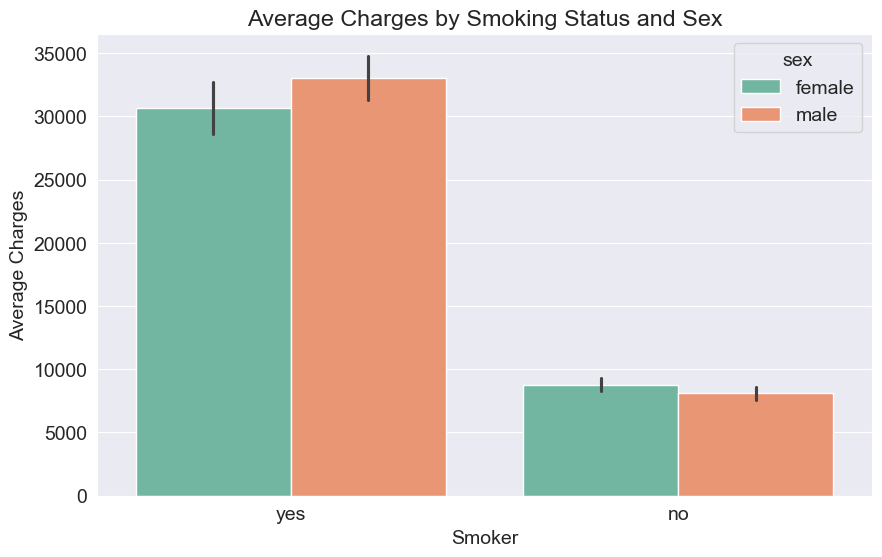

In [14]:
fig = sns.barplot(x="smoker", y="charges", data=medical_df, hue="sex", palette="Set2")
fig.set_title("Average Charges by Smoking Status and Sex")
fig.set_xlabel("Smoker")
fig.set_ylabel("Average Charges")
plt.show()

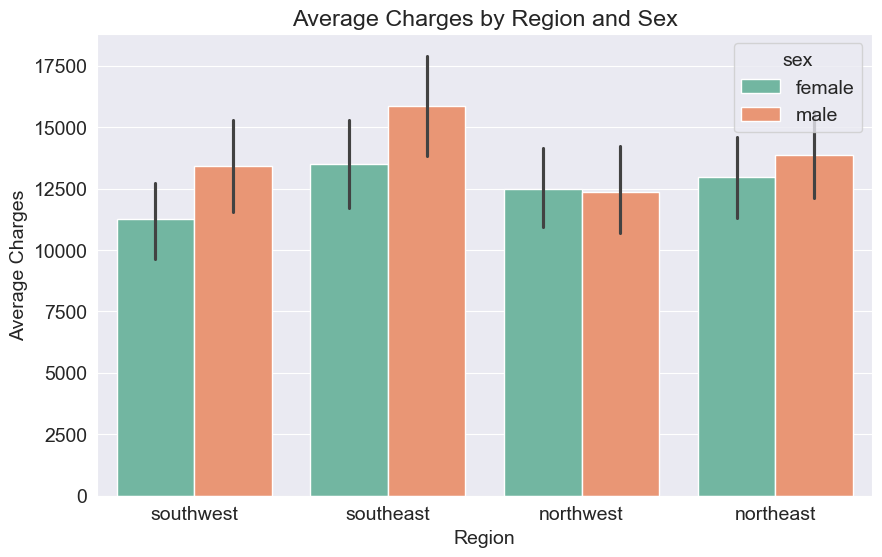

In [15]:
fig = sns.barplot(x="region", y="charges", data=medical_df, hue="sex", palette="Set2")
fig.set_title("Average Charges by Region and Sex")
fig.set_xlabel("Region")
fig.set_ylabel("Average Charges")
plt.show()

In [16]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

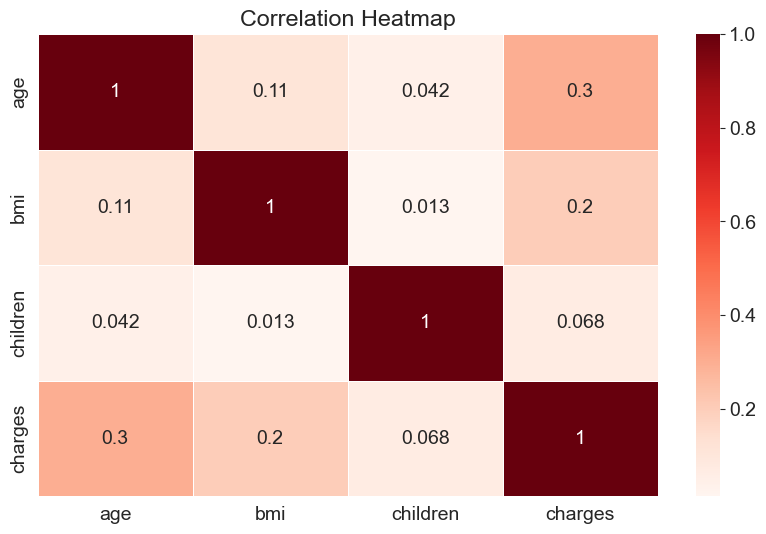

In [17]:
sns.heatmap(medical_df.corr(numeric_only=True), annot=True, cmap="Reds", linewidths=0.5)
plt.title("Correlation Heatmap")

In [18]:
smoker_values = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df['smoker'].map(smoker_values)

In [19]:
medical_df.charges.corr(medical_df['smoker_code'])

0.7872514304984778

In [20]:
sex_values = {'female': 0, 'male': 1}
medical_df['sex_code'] = medical_df['sex'].map(sex_values)

<Axes: xlabel='region', ylabel='charges'>

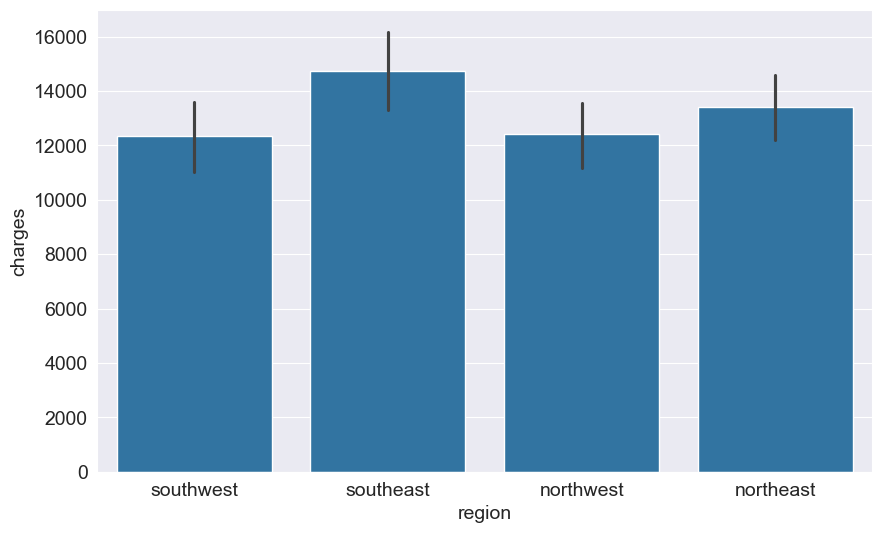

In [21]:
sns.barplot(data=medical_df, x='region', y='charges')

In [22]:
# feature scaling age and bmi
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
medical_df[['age', 'bmi', 'children']] = scaler.fit_transform(medical_df[['age', 'bmi', 'children']])

In [23]:
print(scaler.mean_)
print(scaler.var_)

[39.20702541 30.66339686  1.09491779]
[197.25385199  37.16008997   1.45212664]


In [24]:
from sklearn import preprocessing

enc = preprocessing.OneHotEncoder()
region_encoded = enc.fit_transform(medical_df[['region']])
region_encoded_df = pd.DataFrame(region_encoded.toarray(), columns=enc.get_feature_names_out(['region']))
medical_df = pd.concat([medical_df, region_encoded_df], axis=1)

In [ ]:
# model for smoker is 'yes' using linear regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

smoker_yes_df = medical_df[medical_df['smoker'] == 'yes']
X = smoker_yes_df[['age', 'bmi', 'sex_code', 'children', 'region_northeast','region_northwest', 'region_southeast', 'region_southwest']]
y = smoker_yes_df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error  
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Root Mean Squared Error: {rmse}")


Mean Absolute Error: 4774.733235698314
Mean Squared Error: 44861467.898557305
R-squared: 0.7010154827060613
Root Mean Squared Error: 6697.870400250911


In [ ]:
# model for non-smoker using linear regression
smoker_no_df = medical_df[medical_df['smoker'] == 'no']
X = smoker_no_df[['age', 'bmi', 'sex_code', 'children', 'region_northeast','region_northwest', 'region_southeast', 'region_southwest']]
y = smoker_no_df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Root Mean Squared Error: {rmse}")



Mean Absolute Error: 2422.0003835219954
Mean Squared Error: 19039670.721685372
R-squared: 0.45768936754649603
Root Mean Squared Error: 4363.447114574138


In [ ]:
# model for all the data
X = medical_df[['age', 'bmi', 'smoker_code', 'sex_code', 'children', 'region_northeast','region_northwest', 'region_southeast', 'region_southwest']]
y = medical_df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Root Mean Squared Error: {rmse}")



Mean Absolute Error: 4181.19447375365
Mean Squared Error: 33596915.85136146
R-squared: 0.7835929767120723
Root Mean Squared Error: 5796.2846592762735


In [28]:
# model improvement 
# feature scaling
print(model.coef_)
print(X.columns)

[ 3.60914902e+03  2.05488506e+03  2.36511289e+04 -1.85916916e+01
  5.12478869e+02  8.89079180e+01 -1.98279052e+02 -3.50214110e+02
  4.59585244e+02]
Index(['age', 'bmi', 'smoker_code', 'sex_code', 'children', 'region_northwest',
       'region_southeast', 'region_southwest', 'region_northeast'],
      dtype='object')
